In [1]:
import pandas as pd
import numpy as np
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer

In [15]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [12]:
import torchvision

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True)

X_train, y_train = train_dataset.data, train_dataset.targets
X_test, y_test = test_dataset.data, test_dataset.targets

print("X_train shape:", X_train.shape) 
print("y_train shape:", y_train.shape) 
print("X_test shape: ", X_test.shape) 
print("y_test shape:  ", y_test.shape) 

X_train shape: torch.Size([60000, 28, 28])
y_train shape: torch.Size([60000])
X_test shape:  torch.Size([10000, 28, 28])
y_test shape:   torch.Size([10000])


In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

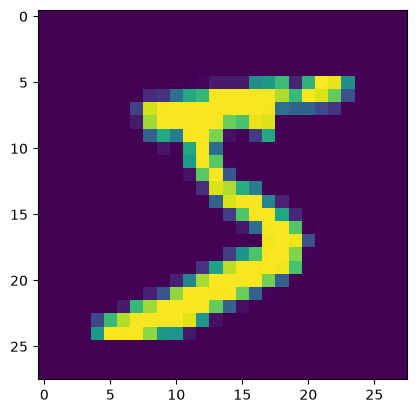

In [14]:
plt.imshow(X_train[0])
plt.show()

In [16]:
class MyDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, x):
        return self.features[x], self.labels[x]

In [17]:
train_dataset = MyDataSet(X_train, y_train)
test_dataset = MyDataSet(X_test, y_test)

In [28]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle = False, pin_memory=True)

In [24]:
class MyANN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.model(x)

In [32]:
learning_rate = 0.001
epochs = 10

In [33]:
model = MyANN(input_dim=784, output_dim=10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [42]:
model.eval()

MyANN(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [43]:
y_preds = []
y_true = []
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        outputs = model(batch_features)
        preds = torch.argmax(outputs, dim=1)
        y_preds.extend(preds.cpu().numpy())
        y_true.extend(batch_labels.numpy())

print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.97      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.96      0.97       892
           6       0.99      0.98      0.99       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

